<a href="https://colab.research.google.com/github/ferbeiro/calculo-numerico/blob/main/Atividade_Calculo_Numerico_Estabilidade_Overflow_Fernanda_Ribeiro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico — Atividade Prática II

Integrante: Fernanda Ribeiro

## 1. Verificação da estabilidade


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

H = 0.01
nu = 1e-4
U = 1.0
pontos = 21

dy = H / (pontos - 1)
dt_max = dy**2 / (2 * nu)

print(f"Delta y = {dy:.7f} m")
print(f"Delta t_max = {dt_max:.7f} s")

for dt in (0.001, 0.002):
    r = nu * dt / dy**2
    classificacao = "Estável" if r <= 0.5 else "Instável"
    print(f"dt = {dt:.4f} s | r = {r:.2f} | {classificacao}")

Delta y = 0.0005000 m
Delta t_max = 0.0012500 s
dt = 0.0010 s | r = 0.40 | Estável
dt = 0.0020 s | r = 0.80 | Instável


## 2. Simulação e detecção de overflow


In [ ]:
def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                novo[1:-1] = (
                    u[1:-1]
                    + r * (u[2:] - dois * u[1:-1] + u[:-2])
                )
            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308


dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


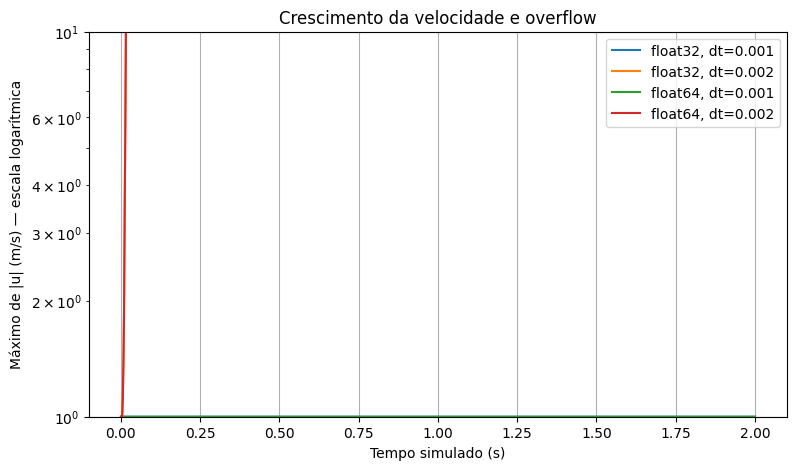

In [ ]:
resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s) — escala logarítmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
linhas = []

for nome, resultado in resultados.items():
    tipo_nome, dt_texto = nome.split(", dt=")
    dt = float(dt_texto)

    linhas.append({
        "Tipo numérico": tipo_nome,
        "Passo dt (s)": dt,
        "r": resultado["r"],
        "Overflow": "Sim" if resultado["falha"] is not None else "Não",
        "Iteração da falha": resultado["falha"] if resultado["falha"] is not None else "-"
    })

tabela = pd.DataFrame(linhas)
tabela

,Tipo numérico,Passo dt (s),r,Overflow,Iteração da falha
0,float32,0.001,0.4,Não,-
1,float32,0.002,0.8,Sim,121
2,float64,0.001,0.4,Não,-
3,float64,0.002,0.8,Sim,917


### 3. Interpretação física

A velocidade física deve permanecer no intervalo

$$
0\leq u(y,t)\leq U=1\,m/s.
$$

No caso estável, a solução permanece fisicamente correta e tende ao perfil estacionário. Já no caso com $r=0{,}8$, o coeficiente central da atualização,

$$
1-2r=1-1{,}6=-0{,}6,
$$

é negativo. Assim, a atualização deixa de ser uma média ponderada com coeficientes não negativos.

Portanto, o crescimento da velocidade no caso instável não representa o comportamento físico do fluido. A solução já está numericamente incorreta antes mesmo de ocorrer overflow.

## 4. Capacidade de representação: float32 × float64

O `float32` possui maior valor finito aproximado de

$$
3{,}4\times10^{38},
$$

enquanto o `float64` chega aproximadamente a

$$
1{,}8\times10^{308}.
$$

Trocar `float32` por `float64` não elimina a instabilidade. A condição de estabilidade continua sendo determinada por $r$, portanto o caso $r=0{,}8$ continua instável.

A diferença é que o `float64` consegue representar números muito maiores antes de ocorrer overflow. Por isso, ele pode levar mais passos para atingir a faixa máxima representável no caso instável.

## 5. Refinamento da malha


41 pontos:
Delta y = 0.0002500 m
Delta t_max = 0.0003125 s
dt = 0.0010 s -> r = 1.60
dt = 0.0002 s -> r = 0.32
dt=0.0002, float64: 5000 passos sem overflow.


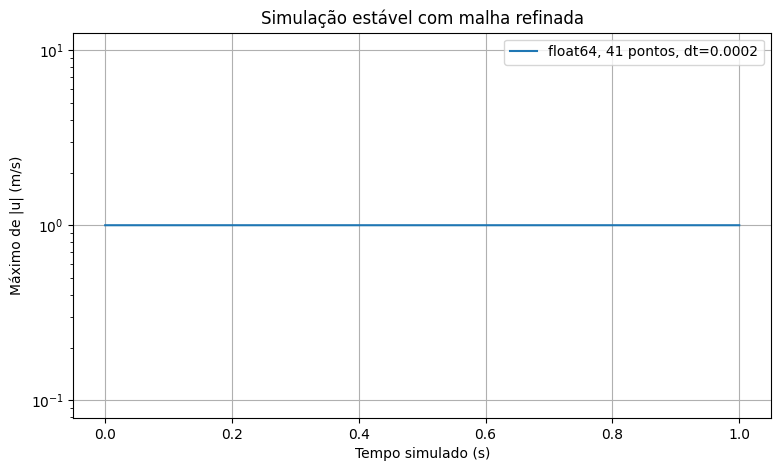

In [ ]:
pontos_ref = 41
dy_ref = H / (pontos_ref - 1)
dt_max_ref = dy_ref**2 / (2 * nu)

dt_instavel_ref = 0.001
r_instavel_ref = nu * dt_instavel_ref / dy_ref**2

dt_estavel_ref = 0.0002
r_estavel_ref = nu * dt_estavel_ref / dy_ref**2

print(f"41 pontos:")
print(f"Delta y = {dy_ref:.7f} m")
print(f"Delta t_max = {dt_max_ref:.7f} s")
print(f"dt = {dt_instavel_ref:.4f} s -> r = {r_instavel_ref:.2f}")
print(f"dt = {dt_estavel_ref:.4f} s -> r = {r_estavel_ref:.2f}")

resultado_ref = simular(
    dt_estavel_ref,
    tipo=np.float64,
    passos=5000,
    pontos=41
)

plt.figure(figsize=(9, 5))
plt.semilogy(
    resultado_ref["tempos"],
    resultado_ref["maximos"],
    label="float64, 41 pontos, dt=0.0002"
)
plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s)")
plt.title("Simulação estável com malha refinada")
plt.grid(True)
plt.legend()
plt.show()

### Discussão do refinamento

O refinamento da malha diminui $\Delta y$. Como o limite de estabilidade depende de $\Delta y^2$, uma malha mais fina exige um passo de tempo menor.

Assim, simplesmente aumentar o número de pontos mantendo $\Delta t=0{,}001\,s$ piora a estabilidade. Para a malha de 41 pontos, é necessário reduzir o passo para abaixo de $0{,}0003125\,s$.

A configuração $\Delta t=0{,}0002\,s$, com $r=0{,}32$ faz sentido de acordo com a condição de estabilidade.

## 6. Verificação do perfil de velocidade

dt=0.0002, float64: 20000 passos sem overflow.
Tempo simulado = 4.0000 s
Erro máximo E_inf = 1.54321000e-14 m/s


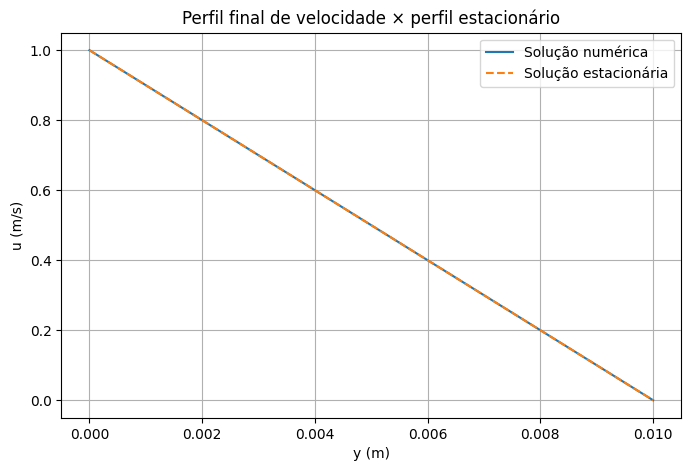

In [ ]:
# Execução estável longa para aproximar o regime estacionário
resultado_final = simular(
    dt=0.0002,
    tipo=np.float64,
    passos=20000,
    pontos=41
)

y_final = resultado_final["y"]
u_final = resultado_final["u"]

u_est = U * (1 - y_final / H)
erro_inf = np.max(np.abs(u_final - u_est))

print(f"Tempo simulado = {20000 * 0.0002:.4f} s")
print(f"Erro máximo E_inf = {erro_inf:.8e} m/s")

plt.figure(figsize=(8, 5))
plt.plot(y_final, u_final, label="Solução numérica")
plt.plot(y_final, u_est, "--", label="Solução estacionária")
plt.xlabel("y (m)")
plt.ylabel("u (m/s)")
plt.title("Perfil final de velocidade × perfil estacionário")
plt.grid(True)
plt.legend()
plt.show()

### Discussão do perfil

A solução estacionária é linear, variando de $1\,m/s$ na placa móvel até $0\,m/s$ na placa fixa.

Em uma execução estável e suficientemente longa, o perfil numérico deve se aproximar dessa reta. A diferença máxima calculada,

$$
E_\infty=\max_i|u_i-u_{est}(y_i)|,
$$

mede quantitativamente essa aproximação.

Se o erro ainda não for muito pequeno, isso pode ocorrer porque o tempo simulado ainda contém efeitos do transiente: a solução precisa de tempo para que a difusão de velocidade atravesse todo o domínio.

## 7. Conclusão

A atividade mostra que instabilidade numérica e overflow não são a mesma coisa. A instabilidade ocorre quando o método utilizado deixa de satisfazer sua condição de estabilidade, podendo amplificar erros e produzir valores fisicamente incorretos. O overflow pode aparecer depois, quando esses valores ultrapassam a capacidade de representação do tipo numérico.

Para a malha original, com 21 pontos:

$$
\Delta y=0{,}0005\,m,\qquad
\Delta t_{max}=0{,}00125\,s.
$$

Assim:

- $dt=0{,}001\,s$ → $r=0{,}4$ → **estável**;
- $dt=0{,}002\,s$ → $r=0{,}8$ → **instável**.

A mudança de `float32` para `float64` aumenta a faixa de números representáveis e pode atrasar o overflow, mas não corrige a causa da instabilidade.

O refinamento da malha para 41 pontos reduziu o espaçamento para $0{,}00025\,m$ e o limite de estabilidade para $0{,}0003125\,s$. Portanto, foi necessário reduzir também o passo de tempo. A configuração com $dt=0{,}0002\,s$, que produz $r=0{,}32$, é estável.